In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from nugget.geometries.base_geometry import compare_geometries
from scipy.spatial.distance import squareform
# from sklearn.manifold import MDS
import time
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve
import sys
import pandas as pd
from scipy import stats
from scipy.integrate import cumulative_trapezoid

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [3]:
device = 'cuda:2'
importlib.reload(nugget.surrogates.LightSabre)
patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
        device=device,
        use_poisson=False,
        num_track_points=1000,
        domain_size=2000,
        use_max_energy_dist=True,
        use_perpendicular_distance_only=True,
        particle_mode='track',
        )
light_yield_surrogate_patd = patd_surrogate.light_yield_surrogate
lightsabre = nugget.surrogates.LightSabre.LightSabre(
                device=device,
                use_poisson=False, 
                num_track_points=2000, 
                domain_size=2000,
                particle_mode='track',
                )
light_yield_surrogate = lightsabre.light_yield_surrogate
batched_light_yield_surrogate = lightsabre.light_yield_surrogate_batched

signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
        device=device,
        event_type='signal',
        domain_size=2000,
        E_min=1e2,
        E_max=1e8,
        energy_dist='log_uniform',
        find_exact_intersection=False,
        random_position_along_ray=False,
        box_intersection=True,
        uniform_zenith_sampling=True,
        )

In [5]:
importlib.reload(nugget.surrogates.LLRnet)

llr_net = nugget.surrogates.LLRnet.LLRnet(
    device=device,
    domain_size=2500,
    dim=3,
    hidden_dims=[64, 64, 64, 64, 64, 64],
    use_fourier_features=False,
    num_parallel_branches=1,
    learnable_frequencies=False,
    dropout_rate=0.05,
    learning_rate=3e-4,
    shared_mlp=False,
    use_residual_connections=True,
    signal_noise_scale=0,
    background_noise_scale=0,
    # add_relative_pos / log_scale_ly / norm_pos / log_scale_energy are unused
    # when use_rich_features=True; prepare_features_patd handles normalisation internally.
    add_relative_pos=False,
    log_scale_ly=True,
    norm_pos=True,
    log_scale_energy=True,
    
    reduce_lr_on_plateau=True,
    lr_scheduler_patience=30,
    lr_scheduler_factor=0.5,
    lr_scheduler_min_lr=1e-6,
    min_photons=1,
    num_photons_per_sample=None,
    input_charge=False,
    rel_time=True,
    input_delta_time=False,  # residual time is baked into prepare_features_patd as t_geom_min
    use_rich_features=True,
    add_distance_from_beam=False,
    use_patd=False,
    add_vertex_distance=True,
)

llr_net.load_model('llrnet_models/best_hit_llr_model_v8.pt')
# llr_net.load_model('llrnet_models/best_charge_llr_model_v5.pt')
# llr_net.load_model('llrnet_models/best_mc_ly_muon_llr_model_v1.pt')
# history = pickle.load(open('hit_llr_v7_training_history.pkl', 'rb'))
# history = pickle.load(open('charge_llr_v5_training_history.pkl', 'rb'))
# marginalised_ly = torch.load('llrnet_models/charge_llr_v6_training_ly.pt')

Building parallel network architecture:
  Input dim: 11
  Number of parallel branches: 1
  Shared MLP: False
  Branch 0 MLP with residual connections: 11 -> [64, 64, 64, 64, 64, 64] -> 64
  Final MLP: 64 -> 32 -> 1
  Total trainable parameters: 27,841


In [14]:
#print llr_net object parameters
for param in llr_net.__dict__:
    print(f"{param}: {llr_net.__dict__[param]}")

device: cpu
dim: 3
domain_size: 2000
hidden_dims: [64, 64, 64, 64, 64, 64]
dropout_rate: 0
learning_rate: 0.0001
use_fourier_features: False
num_frequencies: 64
frequency_scale: 1.0
learnable_frequencies: False
num_parallel_branches: 1
shared_mlp: False
use_residual_connections: True
signal_noise_scale: 0.0
background_noise_scale: 0.0
add_relative_pos: False
add_distance_from_beam: True
log_scale_ly: True
rel_time: True
flag_negative_times: False
input_charge: False
norm_pos: True
log_scale_energy: True
use_rich_features: True
reduce_lr_on_plateau: True
lr_scheduler_patience: 30
lr_scheduler_factor: 0.5
lr_scheduler_min_lr: 1e-06
add_vertex_distance: False
use_patd: True
min_photons: 1
input_delta_time: False
num_photons_per_sample: 16
jitter_time: 0.0
frequency_scales: [1.0]
num_frequencies_per_branch: [64]
fourier_features_list: None
mlp_branches: ModuleList(
  (0): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): SiLU()
    (2): Dropout(p=0, inplace=F

In [40]:
true_event = signal_sampler.sample_events(1)[0]
true_event['energy']

tensor([1642.2256], device='cuda:2')

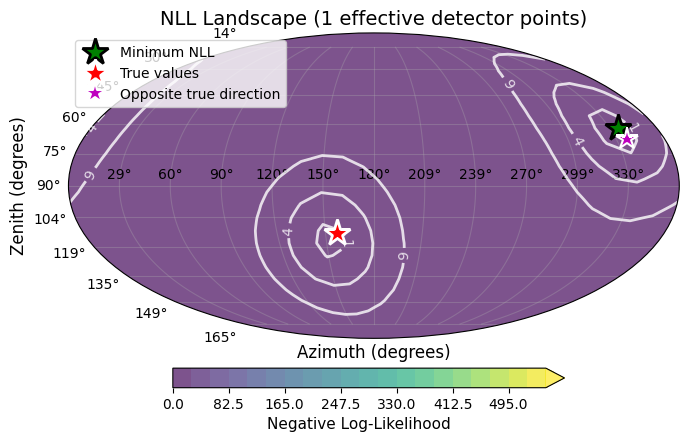

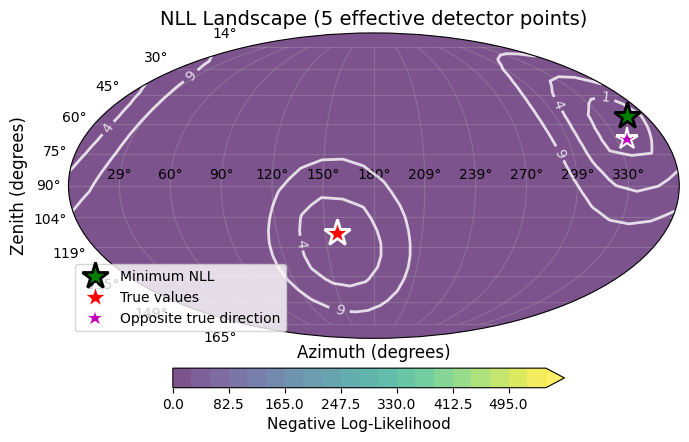

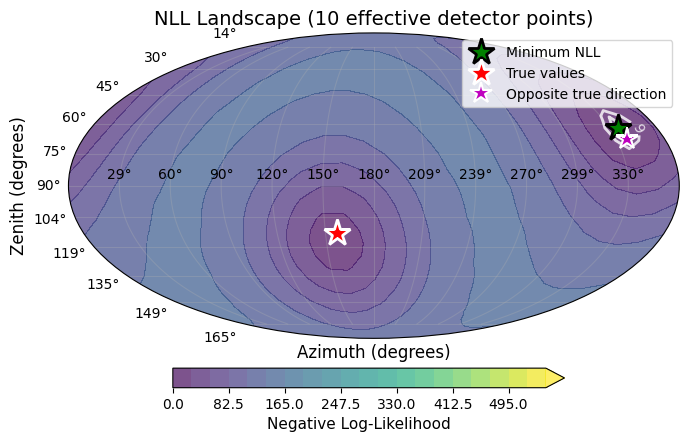

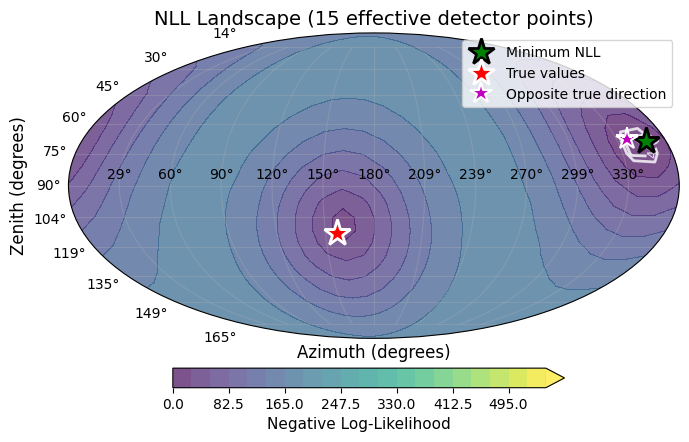

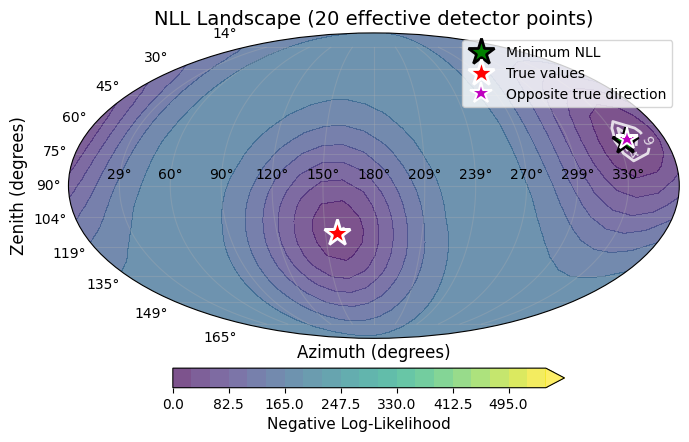

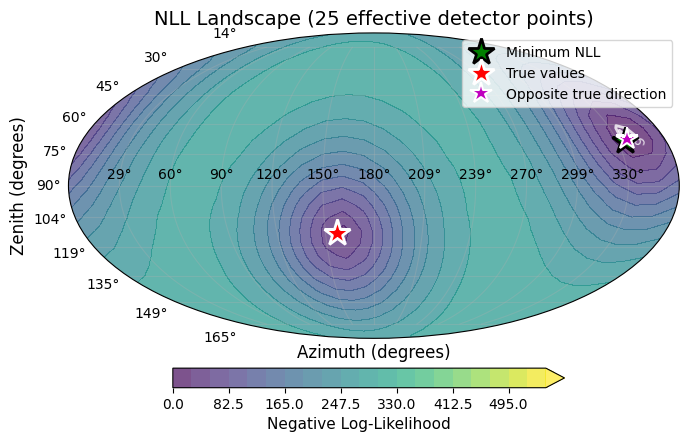

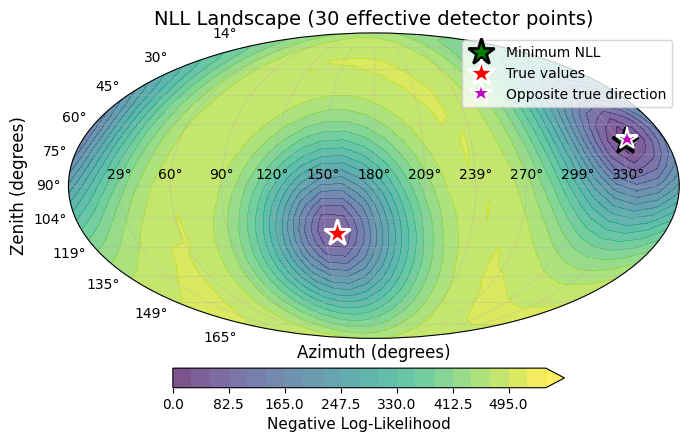

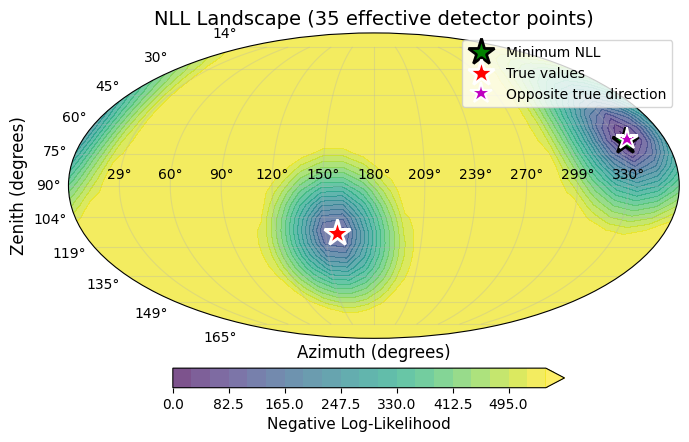

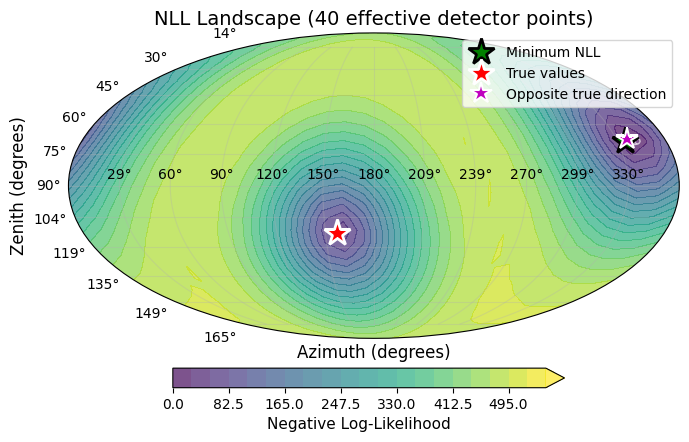

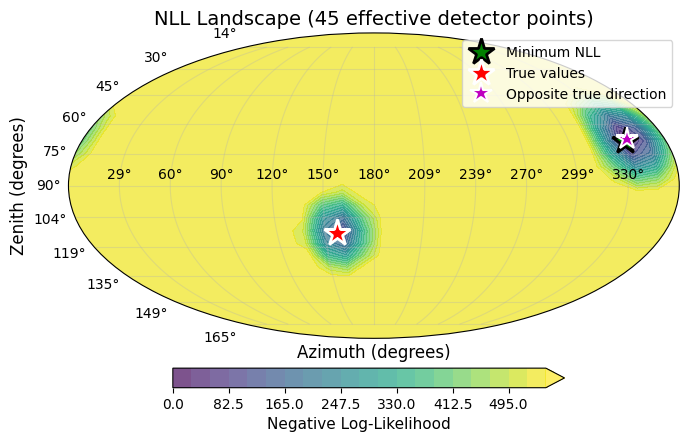

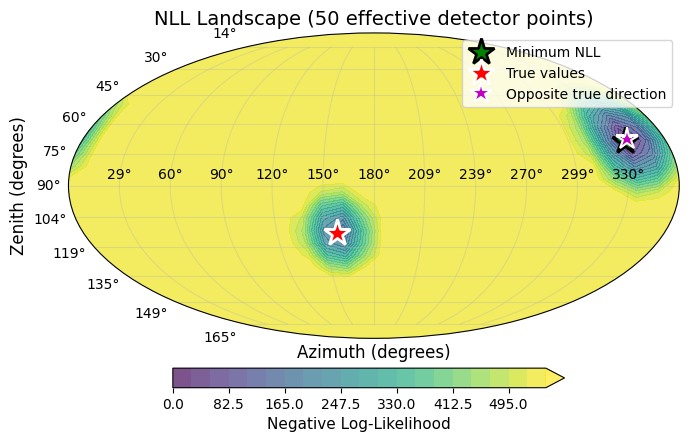

In [44]:
importlib.reload(nugget.utils.vis_tools)
for det_points in range(0,51, 5):
    result = nugget.utils.vis_tools.plot_nll_landscape(
        llrnet=llr_net,
        signal_sampler=signal_sampler,
        signal_surrogate_func=light_yield_surrogate_patd,
        event_labels=['position','energy', 'direction'],
        param_names =['zenith','azimuth'],
        # param_names=['energy'],
        # param_ranges={'energy': (1e2, 1e8)},
        param_ranges={'energy': (1e2, 1e8), 'zenith': (0, np.pi), 'azimuth': (0, 2*np.pi)},
        # param_names=['x', 'y'],
        # param_ranges={'x': (-3, 3), 'y': (-3, 3)},
        figsize=(7,5),
        n_points=30,
        detector_point=None,   
        true_event=true_event,
        use_mollweide=True,
        skip_zero_response=True,
        use_patd = True,
        use_rich_features = True,
        num_detector_points=1000, 
        min_detector_points=det_points,
        min_detector_response=1.0, 
        max_detector_resample_attempts=100000,
        plot_opposite_direction_true_params=True,
        progress_print_every_n_points=None   ,
        nll_cbar_max=550 
    )
    fig = result['fig']
    fig.savefig(f"llr_landscape_detpoints_{det_points}.png", dpi=300, bbox_inches='tight')

In [45]:
from pathlib import Path
import re
import imageio.v3 as iio

# Build a GIF from saved frames: llr_landscape_detpoints_*.png
frames_dir = Path(".")
pattern = "llr_landscape_detpoints_*.png"
output_gif = frames_dir / "llr_landscape_detpoints.gif"
fps = 2

image_paths = list(frames_dir.glob(pattern))

if not image_paths:
    raise FileNotFoundError(f"No images found matching pattern: {pattern}")

def _extract_det_points(path: Path) -> int:
    match = re.search(r"detpoints_(\d+)", path.name)
    return int(match.group(1)) if match else 10**9

image_paths = sorted(image_paths, key=_extract_det_points)
frames = [iio.imread(p) for p in image_paths]

# duration is in milliseconds per frame for imageio.v3.imwrite with .gif
frame_duration_ms = int(round(1000 / fps))
iio.imwrite(output_gif, frames, duration=frame_duration_ms, loop=0)

print(f"Saved GIF: {output_gif.resolve()}")
print(f"Frames used ({len(image_paths)}):")
for p in image_paths:
    print(f"  - {p.name}")

Saved GIF: /ptmp/mpp/kristiantcho/nugget/nugget/examples/llr_landscape_detpoints.gif
Frames used (11):
  - llr_landscape_detpoints_0.png
  - llr_landscape_detpoints_5.png
  - llr_landscape_detpoints_10.png
  - llr_landscape_detpoints_15.png
  - llr_landscape_detpoints_20.png
  - llr_landscape_detpoints_25.png
  - llr_landscape_detpoints_30.png
  - llr_landscape_detpoints_35.png
  - llr_landscape_detpoints_40.png
  - llr_landscape_detpoints_45.png
  - llr_landscape_detpoints_50.png


In [22]:
for key in result.keys():
    print(f"{key}")

fig
ax
true_event
true_nll
min_nll_params
detector_points
eff_num_detector_points
param_grid
nll_grid


In [28]:
np.max(result['nll_grid'])

np.float64(20426.147302269936)

In [30]:
true_event = signal_sampler.sample_events(1)[0]
true_event['energy']

tensor([1686246.3750])

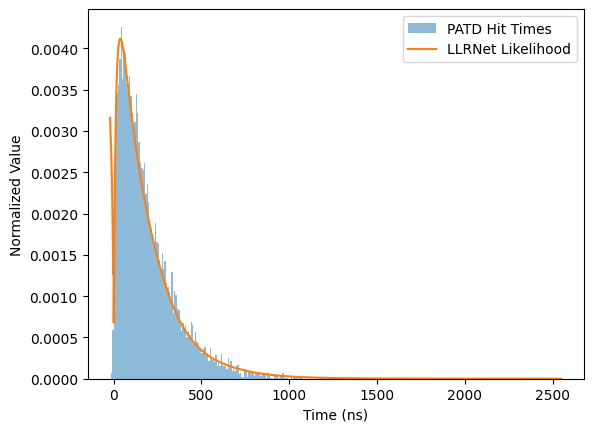

In [25]:
num_photons = 0
while num_photons < 1:
    point = signal_sampler.sample_detector_points(1)[0]
    patd_dict = light_yield_surrogate_patd(opt_point=point, event_params=true_event)
    num_photons = patd_dict['num_photons']
patd_dict = light_yield_surrogate_patd(opt_point=point, event_params=true_event, input_photons=10000)
num_photons = patd_dict['num_photons']
test_event = true_event.copy()
# test_event['direction'] = torch.nn.functional.normalize(test_event['direction'] - torch.tensor([200,0,0]).float(), p=2, dim=0) # flip the direction to test opposite direction
# test_event['zenith'] = np.pi - test_event['zenith']  # flip the zenith to test opposite direction
test_times = torch.logspace(torch.log10((patd_dict['t_geom_min'])-20), torch.log10(max(patd_dict['hit_times'])+1000), steps=3000)
test_patd_dict = {'hit_times': test_times, 'num_photons': 3000, 't_geom_min': patd_dict['t_geom_min']}
features, num_photons = llr_net.prepare_features_patd(point=point, event_data=test_event, patd_result=test_patd_dict)
likelihoods = llr_net.predict_likelihood_ratio(features)

true_likelihoods = torch.exp(patd_surrogate.eval_patd_log_probs(patd_dict['residual_times'], point, true_event))
#plot the hit times as a histogram and the likelihoods as a line plot on the same plot
sorted_inds = torch.argsort(patd_dict['hit_times'])
true_likelihoods = true_likelihoods[sorted_inds]
true_likelihoods = true_likelihoods#/torch.sum(true_likelihoods[torch.isfinite(true_likelihoods)])
plt.hist(patd_dict['hit_times'].cpu().detach().numpy() - patd_dict['t_geom_min'].cpu().detach().numpy(), bins=200, alpha=0.5, label='PATD Hit Times', density=True)
# normalized_likelihoods = likelihoods* / (torch.sum(likelihoods*(test_times[1]-test_times[0])))
# normalize likelihoods by integrating over the test_times range using the trapezoidal rule
normalized_likelihoods = likelihoods / torch.trapz(likelihoods, test_times)
plt.plot(test_times.cpu().detach().numpy() - patd_dict['t_geom_min'].cpu().detach().numpy(), normalized_likelihoods.cpu().detach().numpy(), label='LLRNet Likelihood')
# plt.plot(patd_dict['hit_times'][sorted_inds].cpu().detach().numpy(), true_likelihoods.cpu().detach().numpy(), label='True PATD Likelihood')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized Value')
# plt.title('PATD Hit Times and LLRNet Likelihoods')
# plt.xscale('log')
plt.legend()

In [4]:
def find_llr_charge_peak(llr_net, point, event_parms, *, device,
                          n_scan=64, charge_floor=1e-3, charge_ceil=1e5):
    """Locate, per detector, the charge at which the LLR-net likelihood peaks.

    This depends ONLY on the network: it scans a coarse log-spaced charge grid
    over the full physical range [charge_floor, charge_ceil], evaluates the LLR,
    and returns the per-detector argmax charge. The surrogate output is not used.

    Fully vectorised: one batched network call over (n_points * n_scan) feature
    rows, then a per-row argmax.

    Parameters
    ----------
    eval_llr_on_charges : callable (c_feat_flat) -> llr_flat
        Given a (n_points*n_scan, 1) tensor of log10(charge)/4 features, returns
        the (n_points*n_scan,) LLR values (network evaluated at the fixed θ0
        context for each detector).
    n_points : int
        Number of detectors (batch size B).

    Returns
    -------
    c_peak : (n_points,) charge at the per-detector LLR peak (>0)
    """
    
    log_scan = torch.linspace(np.log10(charge_floor), np.log10(charge_ceil),
                              n_scan, device=device)                        # (n_scan,)
    c_scan = torch.pow(10.0, log_scan)

    likelihoods = []
    for test_charge in c_scan:
        features = llr_net.prepare_features_charge(point=point, event_data=event_parms, light_yield=test_charge)
        likelihoods.append(llr_net.predict_likelihood_ratio(features))
    max_idx = torch.argmax(torch.stack(likelihoods).squeeze(-1))           
    return c_scan[max_idx]

In [53]:
class HistogramMarginalDensity:
    """
    Marginal p(LY) fit once from recorded light yields, reusable for future
    evaluation. Handles a point mass at LY=0 plus a log10(LY) histogram for
    LY>0, skipping empty bins so interpolation only uses bins with support.
    """

    def __init__(self, light_yields, n_bins=50, zero_tol=1e-6):
        light_yields = np.asarray(light_yields, dtype=np.float64)
        is_zero = np.abs(light_yields) <= zero_tol

        self.zero_tol = zero_tol
        self.p_zero = is_zero.mean()

        positive_ly = light_yields[~is_zero]
        positive_ly = positive_ly[positive_ly > 0]
        log_ly = np.log10(positive_ly)

        counts, bin_edges = np.histogram(log_ly, bins=n_bins, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # keep only bins that actually contain data
        nonempty = counts > 0
        self.bin_centers = bin_centers[nonempty]
        self.counts = counts[nonempty]

    def __call__(self, ly_values):
        """
        Evaluate p(LY) at new light-yield values using the fitted histogram.
        Returns 0 outside the range spanned by non-empty bins.
        """
        ly_values = np.asarray(ly_values, dtype=np.float64)
        density = np.zeros_like(ly_values)

        positive_mask = ly_values > self.zero_tol
        log_ly_eval = np.log10(ly_values[positive_mask])

        p_log = np.interp(log_ly_eval, self.bin_centers, self.counts, left=0.0, right=0.0)
        p_ly = p_log / (ly_values[positive_mask] * np.log(10.0))

        density[positive_mask] = (1.0 - self.p_zero) * p_ly
        return density


# --- fit once ---
# recorded = llr_net.recorded_lys  # (N, 5): [x, y, z, light_yield, label]
# mismatched_ly = recorded[recorded[:, 4] == 0][:, 3].numpy()
mismatched_ly = marginalised_ly[marginalised_ly[:, 4] == 0][:, 3].cpu().detach().numpy()
marginal_ly_density = HistogramMarginalDensity(mismatched_ly, n_bins=10000)

In [120]:
true_event = signal_sampler.sample_events(1)[0]
true_event['energy']

tensor([256001.3750])

/tmp/ipykernel_3877089/215784061.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  charge = torch.tensor(charge)
/tmp/ipykernel_3877089/215784061.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_charges = torch.linspace(10**(np.log10(charge)-1), 10**(np.log10(charge)+1), steps=1000)


True Light Yield: 12.80, LLRNet Predicted Charge: 1.00
LLRnet ratio of predicted to true charge: 0.08


/tmp/ipykernel_3877089/215784061.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  likelihoods = likelihoods / torch.trapz(likelihoods, torch.tensor(test_charges))


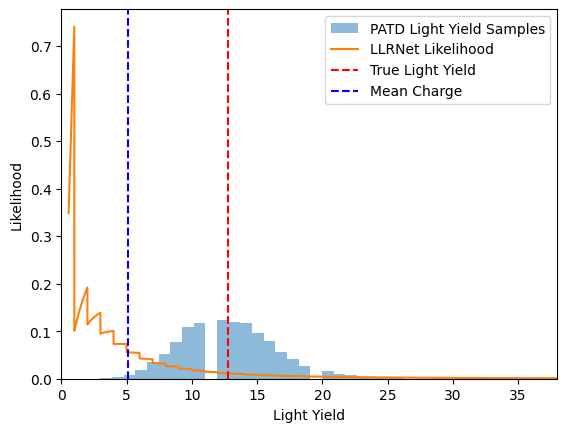

In [ ]:
charge = 0
poisson_k=1.5
w_min=0.3 
w_max=2.0 
charge_floor=1e-4
device = None
n_quadrature = 2000
mag_k = 0.2
charge_ceil = 1e4
assume_poisson = True
num_draws = 10000
while charge <= 10:
    point = signal_sampler.sample_detector_points(1)[0]
    ly = light_yield_surrogate(opt_point=point, event_params=true_event)
    charge = ly.item()
true_charge = charge
charge = find_llr_charge_peak(llr_net, point, true_event, device=device,
                          n_scan=100, charge_floor=charge_floor, charge_ceil=charge_ceil)
charge = torch.tensor(charge)
test_charges = torch.linspace(10**(np.log10(charge)-1), 10**(np.log10(charge)+1), steps=1000)
               
log_lam = torch.log10(charge)                                    
log_floor = np.log10(charge_floor)

# 1. Order-of-magnitude term: scales with decades above the floor.
mag_width = mag_k * (log_lam - log_floor)                     
# 2. Poisson relative width in decades (0.4342944819 = 1/ln(10)).
poisson_width = poisson_k * 0.4342944819 / torch.sqrt(charge)    

width = torch.maximum(mag_width, poisson_width).clamp(min=w_min, max=w_max)  # (B,)

log_lo = torch.clamp(log_lam - width, min=log_floor)                          # (B,)
log_hi = torch.clamp(log_lam + width, max=np.log10(charge_ceil))            # (B,)

alpha = torch.linspace(0.0, 1.0, n_quadrature, device=device)  # (N,)
log_c_grid = log_lo + alpha * (log_hi - log_lo)
test_charges = torch.pow(10.0, log_c_grid)
# test_charges = []
likelihoods = []
# for _ in range(50000):
#     test_ly = 0
#     while test_ly < 1:
#         event = signal_sampler.sample_events(1)[0]
#         test_ly = light_yield_surrogate(opt_point=point, event_params=event)
#     test_charges.append(test_ly)
# kde = llr_net.estimate_marginal_ly_density(point, signal_sampler, light_yield_surrogate, n_samples=10000, min_light_yield=0.1, max_resample_attempts=1000)


for test_charge in test_charges:
    features = llr_net.prepare_features_charge(point=point, event_data=true_event, light_yield=test_charge)
    likelihoods.append(llr_net.predict_likelihood_ratio(features))
    # likelihoods = llr_net.predict_debiased_likelihood(features, test_charges, point=point)
if assume_poisson:
    #make num_draws repeats of point to feed into the surrogate to draw ly samples
    lys= []
    for _ in range(num_draws):
        ly = light_yield_surrogate(opt_point=point, event_params=true_event)
        lys.append(ly)
    lys = torch.stack(lys)
    true_charge = torch.mean(lys)
plt.hist(lys.cpu().detach().numpy(), bins=torch.max(lys).int(), alpha=0.5, label='PATD Light Yield Samples', density=True)
# test_charge_diffs = [test_charges[0]]
# test_charge_diffs.extend(test_charges[1:] - test_charges[:-1])
# test_charge_diffs = torch.stack(test_charge_diffs)
likelihoods = torch.stack(likelihoods).squeeze(-1)
marg_dens_hist = np.histogram(mismatched_ly, bins=int(np.max(mismatched_ly)), density=True)
# marg_dens =marginal_ly_density(test_charges.cpu().detach().numpy())
# marg_dens = torch.tensor(marg_dens) / torch.trapz(torch.tensor(marg_dens), torch.tensor(test_charges))
# likelihoods = likelihoods * marg_dens
# match likelihood corresponding light yield to the marginal density light yields from the mismatched events
marginal_dens = marg_dens_hist[0][test_charges.cpu().detach().numpy().astype(int)]
likelihoods = likelihoods * torch.tensor(marginal_dens)
likelihoods = likelihoods / torch.trapz(likelihoods, torch.tensor(test_charges))

# hist, bin_edges = np.histogram(test_charges, bins=100000, weights=likelihoods.cpu().detach().numpy(), density=True)
# plot hists
# plt.stairs(hist, bin_edges, label='LLRNet Likelihood', color='orange')
plt.plot(test_charges.cpu().detach().numpy(), likelihoods.cpu().detach().numpy(), label='LLRNet Likelihood')
#plot vertical line at the true charge
plt.axvline(x=true_charge, color='red', linestyle='--', label='True Light Yield')
#plot vertical line at the mean charge
# test_charges = torch.stack()
mean_charge = torch.trapz(test_charges * likelihoods, test_charges).detach().cpu().numpy() 
# mean_charge = test_charges[torch.argmax(likelihoods)]
plt.axvline(x=mean_charge, color='blue', linestyle='--', label='Mean Charge')
# plt.axvline(x=test_charges[torch.argmin(likelihoods)].item(), color='green', linestyle='--', label='LLRNet Predicted Charge')
plt.xlabel('Light Yield')
plt.ylabel('Likelihood')
# plt.title('LLRNet Charge Likelihood')
plt.xlim(0, lys.max().item()+10)
plt.legend()
print(f'True Light Yield: {true_charge:.2f}, LLRNet Predicted Charge: {test_charges[torch.argmax(likelihoods)]:.2f}')
print(f'LLRnet ratio of predicted to true charge: {test_charges[torch.argmax(likelihoods)]/true_charge:.2f}')

In [41]:
test_charges

array([  2.,   0., 762., ...,   0., 291.,   0.],
      shape=(3000,), dtype=float32)

True Light Yield: 30.08, LLRNet Predicted Charge: 1.85
LLRnet ratio of predicted to true charge: 0.06


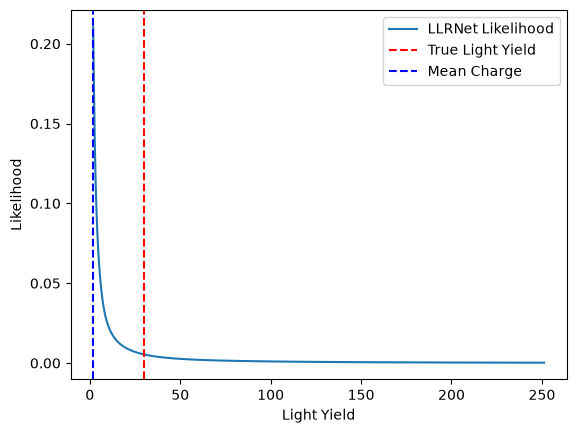

In [46]:
likelihoods = likelihoods / torch.trapz(likelihoods, test_charges)
# hist, bin_edges = np.histogram(test_charges, bins=100000, weights=likelihoods.cpu().detach().numpy(), density=True)
# plot hists
# plt.stairs(hist, bin_edges, label='LLRNet Likelihood', color='orange')
plt.plot(test_charges.cpu().detach().numpy(), likelihoods.cpu().detach().numpy(), label='LLRNet Likelihood')
#plot vertical line at the true charge
plt.axvline(x=true_charge, color='red', linestyle='--', label='True Light Yield')
#plot vertical line at the mean charge
# test_charges = torch.stack()
# mean_charge = torch.trapz(test_charges * likelihoods, test_charges) 
mean_charge = test_charges[torch.argmax(likelihoods)]
plt.axvline(x=mean_charge, color='blue', linestyle='--', label='Mean Charge')
# plt.axvline(x=test_charges[torch.argmin(likelihoods)].item(), color='green', linestyle='--', label='LLRNet Predicted Charge')
plt.xlabel('Light Yield')
plt.ylabel('Likelihood')
# plt.title('LLRNet Charge Likelihood')
# plt.xlim(0, lys.max().item())
plt.legend()
print(f'True Light Yield: {true_charge:.2f}, LLRNet Predicted Charge: {test_charges[torch.argmax(likelihoods)]:.2f}')
print(f'LLRnet ratio of predicted to true charge: {test_charges[torch.argmax(likelihoods)]/true_charge:.2f}')

LightYieldParquetDataset: dropped 450313 row(s) with muon vertex outside domain half-extents [15000.0, 15000.0, 15000.0].
Picked row 50135152: true LY = 1.0, E_nu = 1.42e+04 GeV, zenith = 1.557 rad
LightYieldParquetDataset: dropped 450313 row(s) with muon vertex outside domain half-extents [15000.0, 15000.0, 15000.0].


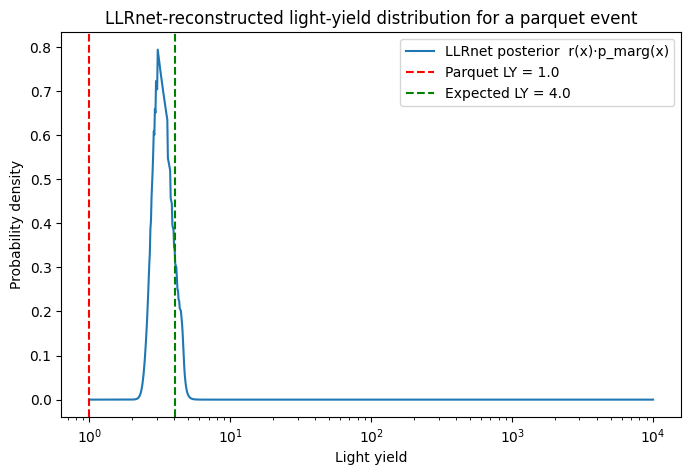

Parquet LY:  1.00
Expected LY: 4.03
Ratio expected/true: 4.03


In [ ]:


# ---- config ----
parquet_path = "new_accepted_photons_ly_all.parquet"   # <-- your parquet
geometry_csv_path = "../other/800_40_40_geom.csv"     # <-- your geometry CSV
device       = llr_net.device

# ---- 1. Build the dataset once (gives us rows + event_data builder) ----
#     add_pmt_direction / uniform_energy_zenith etc. are read from the model as usual.
ds = llr_net.LightYieldParquetDataset(
    llrnet_instance=llr_net,
    parquet_path=parquet_path,
    geometry_csv_path=geometry_csv_path,
    seed=None,
)



# ---- 3. Marginalized LY PDF from the LLRnet built-in (LY >= 1, log-interpolated) ----
pdf_fit = llr_net.compute_light_yield_pdf(parquet_path, geometry_csv_path)
marginal_pdf = pdf_fit['pdf']                        # callable: linear LY -> density




Picked row 44511750: true LY = 798.0, E_nu = 143 GeV, zenith = 2.534 rad


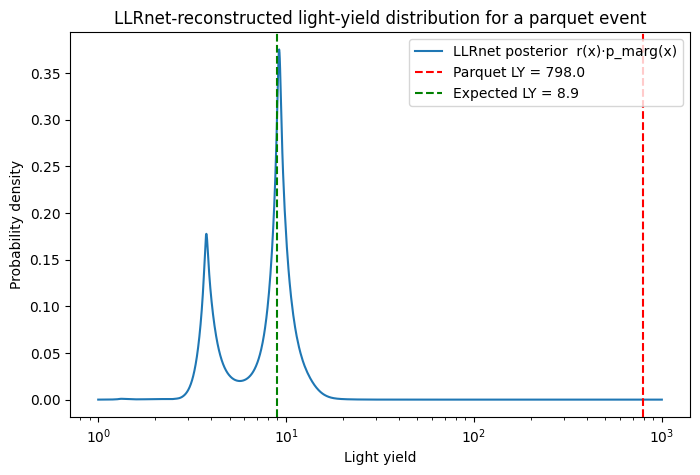

Parquet LY:  798.00
Expected LY: 8.91
Ratio expected/true: 0.01


In [35]:
charge_floor = 1                     # marginal PDF is built for LY >= 1
charge_ceil  = 1e3
n_grid       = 20000
true_charge =0
# ---- 2. Pick a random row (event + its light yield) from the parquet ----
while true_charge < 50:    
    rng = np.random.default_rng(None)
    row = int(rng.integers(0, ds._n_rows))
    true_charge = float(ds._count[row])                 # the LY recorded at this PMT
event_data  = ds._event_data(row)                   # matches training features exactly
point       = torch.tensor(ds._point[row], device=device, dtype=torch.float32)  # OM position
print(f"Picked row {row}: true LY = {true_charge:.1f}, "
      f"E_nu = {ds._energy[row]:.3g} GeV, zenith = {ds._zenith[row]:.3f} rad")

# ---- 4. Likelihood profile over a log-spaced LY grid ----
log_lo = np.log10(max(charge_floor, 1.0))
log_hi = np.log10(charge_ceil)
test_charges = torch.logspace(log_lo, log_hi, steps=n_grid, device=device)

likelihoods = []
for tc in test_charges:
    feats = llr_net.prepare_features_charge(point=point, event_data=event_data, light_yield=tc)
    likelihoods.append(llr_net.predict_likelihood_ratio(feats))
likelihoods = torch.stack(likelihoods).squeeze(-1).detach().cpu()   # r(x) = p(x|theta)/p_marg(x)

# ---- 5. Reconstruct p(LY | event) = r(x) * p_marginal(x), then normalize ----
x_np      = test_charges.detach().cpu().numpy()
marg_dens = torch.tensor(marginal_pdf(x_np), dtype=torch.float64)
posterior = likelihoods.to(torch.float64) * marg_dens
posterior = posterior / torch.trapz(posterior, test_charges.detach().cpu().to(torch.float64))

# ---- 6. Expected LY under the reconstructed distribution ----
xc = test_charges.detach().cpu().to(torch.float64)
expected_ly = torch.trapz(xc * posterior, xc).item()

# ---- 7. Plot ----
plt.figure(figsize=(8, 5))
plt.plot(x_np, posterior.numpy(), label='LLRnet posterior  r(x)·p_marg(x)', color='tab:blue')
plt.axvline(true_charge,  color='red',  ls='--', label=f'Parquet LY = {true_charge:.1f}')
plt.axvline(expected_ly,  color='green', ls='--', label=f'Expected LY = {expected_ly:.1f}')
plt.xscale('log')
plt.xlabel('Light yield')
plt.ylabel('Probability density')
plt.legend()
plt.title('LLRnet-reconstructed light-yield distribution for a parquet event')
plt.show()

print(f"Parquet LY:  {true_charge:.2f}")
print(f"Expected LY: {expected_ly:.2f}")
print(f"Ratio expected/true: {expected_ly / true_charge:.2f}")

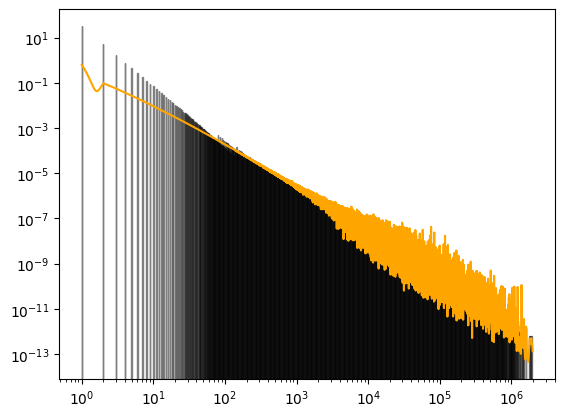

In [39]:
# pdf_fit = llr_net.compute_light_yield_pdf(parquet_path, geometry_csv_path, num_points=100)
# marginal_pdf = pdf_fit['pdf']   
bins = np.logspace(np.log10(pdf_fit['values'].min()), np.log10(pdf_fit['values'].max()), 1000)
plt.hist(pdf_fit['values'], bins=bins, weights=pdf_fit['weights'], density=True, label='PDF', color='tab:blue', alpha=0.5, fill=False)
scatter_points = np.logspace(np.log10(pdf_fit['values'].min()), np.log10(pdf_fit['values'].max()), 100000)
plt.plot(scatter_points, pdf_fit['pdf'](scatter_points), label='Fitted PDF', color='orange')
plt.xscale('log')
plt.yscale('log')

In [27]:
max(likelihoods)

tensor(-3.0123e-20, grad_fn=<UnbindBackward0>)

8988 8988 8988

Evaluation Results:
Accuracy: 0.8059
AUC: 0.8779
Precision: 0.7738
Recall: 0.8645


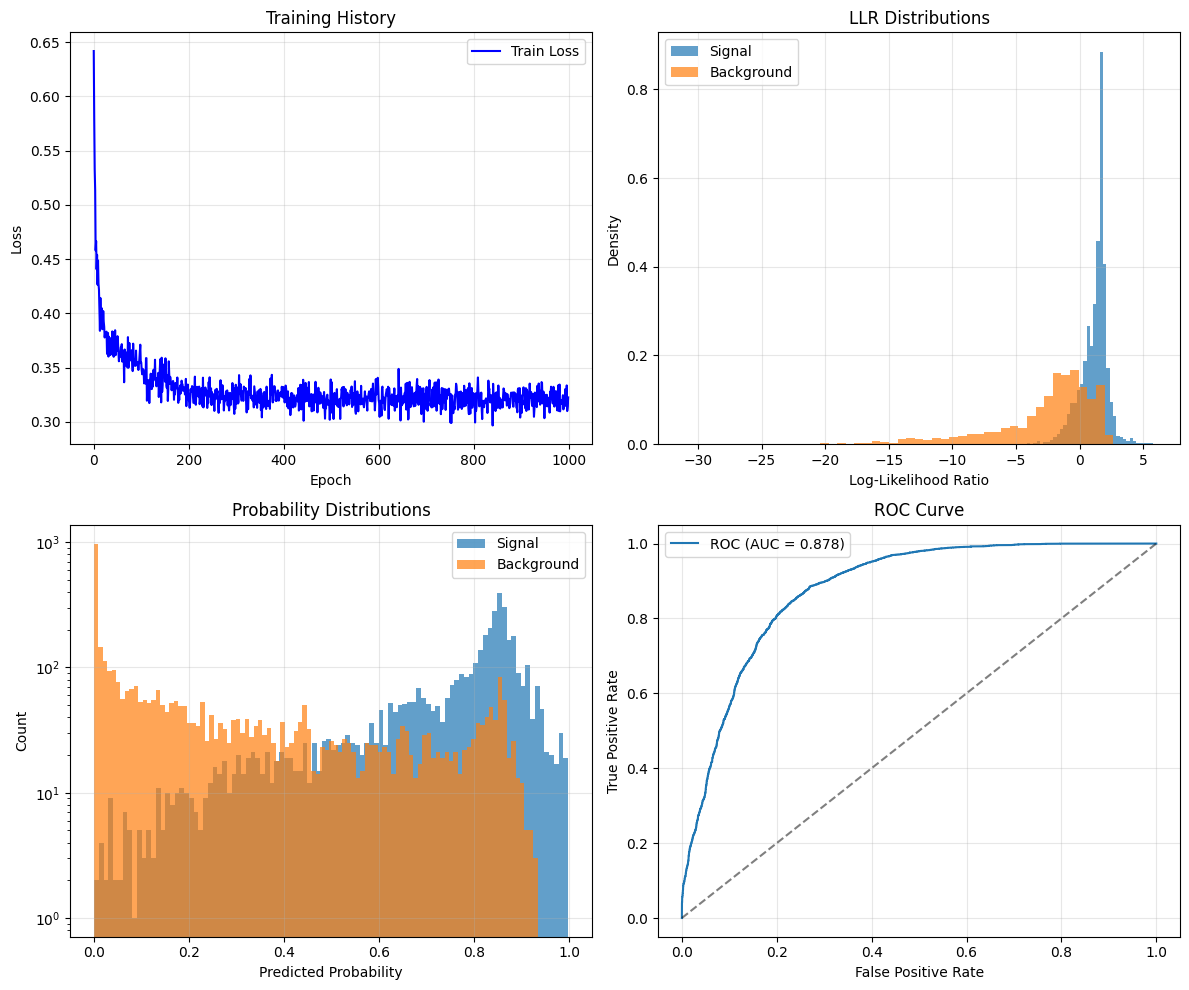

In [19]:
# test_dataloader = llr_net.create_signal_only_dataloader(
#     signal_sampler=signal_sampler, 
#     signal_surrogate_func=light_yield_surrogate,
#     num_samples_per_epoch=1000,
#     batch_size=500,       # Size of each batch (N pairs)
#     num_workers=4,
#     event_labels=['position','energy', 'direction'],
#     shuffle=True,
#     samples_per_event = 1,
#     min_light_yield=0.1,         
#     max_resample_attempts=30,
#     vary_cylinder=False,
#     output_true_light_yield=True,
#     # cylinder_sampler=nugget.samplers.cyl_sampler.CylinderSampler
#     )

test_dataloader = llr_net.create_patd_dataloader(
    signal_sampler=signal_sampler,
    signal_surrogate_func=light_yield_surrogate_patd,
    num_samples_per_epoch=512,
    batch_size=32,
    num_workers=4,
    shuffle_photons=True,
   
)

predictions = []
true_labels = []
llr_values = []
all_features = []
denoised_values = []
with torch.no_grad():
    # for features, labels, denoised in test_dataloader:
    for features, labels in test_dataloader:
        # Get LLR predictions
        batch_llr = llr_net.predict_log_likelihood_ratio(features, epsilon=1e-15)
        batch_probs = llr_net.predict_proba(features)
        # print(len(batch_llr), len(batch_probs), len(labels))
        
        llr_values.extend(batch_llr.cpu().numpy())
        predictions.extend(batch_probs.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        all_features.extend(features.cpu().numpy())  # Store features for further analysis
        # denoised_values.extend(denoised.cpu().numpy())

# Convert to numpy arrays
llr_values = np.array(llr_values)
# llr_values[llr_values < -5] = -5

predictions = np.array(predictions)
true_labels = np.array(true_labels)
all_features = np.array(all_features).squeeze()  # Remove batch dimension if needed
denoised_values = np.array(denoised_values).squeeze()
# ly_mask = denoised_values > 0.1
ly_mask = np.ones_like(true_labels, dtype=bool)
print(len(llr_values), len(predictions), len(true_labels))

# Evaluate performance


binary_preds = (predictions > 0.5).astype(int)
accuracy = accuracy_score(true_labels, binary_preds)
auc = roc_auc_score(true_labels, predictions)
precision = precision_score(true_labels, binary_preds)
recall = recall_score(true_labels, binary_preds)

print(f"\nEvaluation Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Training history
axes[0,0].plot(history['train_loss'], label='Train Loss', color='blue')
# axes[0,0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Training History')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# LLR distributions
signal_mask = true_labels == 1
background_mask = true_labels == 0

axes[0,1].hist(llr_values[signal_mask & ly_mask], bins=50, alpha=0.7, label='Signal', density=True)
axes[0,1].hist(llr_values[background_mask & ly_mask], bins=50, alpha=0.7, label='Background', density=True)
axes[0,1].set_xlabel('Log-Likelihood Ratio')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('LLR Distributions')
# axes[0,1].set_xlim(-5, 5)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Probability distributions
axes[1,0].hist(predictions[signal_mask & ly_mask], bins=100, alpha=0.7, label='Signal', density=False)
axes[1,0].hist(predictions[background_mask & ly_mask], bins=100, alpha=0.7, label='Background', density=False)
axes[1,0].set_xlabel('Predicted Probability')
axes[1,0].set_ylabel('Count')
axes[1,0].set_yscale('log')
axes[1,0].set_title('Probability Distributions')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ROC curve

fpr, tpr, _ = roc_curve(true_labels[ly_mask], predictions[ly_mask])
axes[1,1].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
axes[1,1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curve')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2284145/2562187649.py:12: RuntimeWarning: divide by zero encountered in divide
  llr_density = np.log(binned_sig/binned_bg)
/tmp/ipykernel_2284145/2562187649.py:12: RuntimeWarning: invalid value encountered in divide
  llr_density = np.log(binned_sig/binned_bg)
/tmp/ipykernel_2284145/2562187649.py:12: RuntimeWarning: divide by zero encountered in log
  llr_density = np.log(binned_sig/binned_bg)


(-2.8846664428710938, 3.5145034790039062)

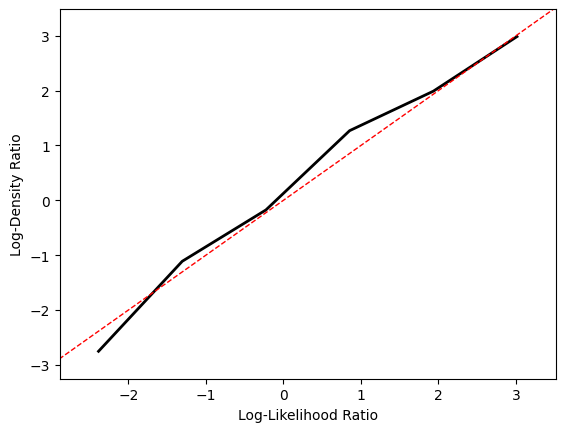

: 

In [ ]:
bg_mask = (true_labels == 0) 
sig_mask = (true_labels == 1) 
binned_bg, bins = np.histogram(llr_values[bg_mask][ly_mask[bg_mask]], bins=70, range=(min(llr_values[ly_mask]), max(llr_values[ly_mask])), density=True)
binned_sig, bins= np.histogram(llr_values[sig_mask][ly_mask[sig_mask]], bins=70, range=(min(llr_values[ly_mask]), max(llr_values[ly_mask])), density=True)
f_vals = (bins[:-1] + bins[1:]) / 2  # Midpoints of bins
# print(f"bin centers: {f_vals}")
# kde_b = gaussian_kde(nn_log_ratios[bg_mask])
# kde_s = gaussian_kde(nn_log_ratios[sig_mask])

# f_vals = np.linspace(-7, 7, 1000)
# llr_density = np.log(kde_s(f_vals) / kde_b(f_vals))
llr_density = np.log(binned_sig/binned_bg)  
# print(f'llr density: {llr_density}')
plt.plot(f_vals, llr_density, 'k-', linewidth=2, label='LLR Density')
plt.plot(f_vals, f_vals, 'r--', linewidth=1)
plt.xlabel('Log-Likelihood Ratio')
plt.ylabel('Log-Density Ratio')
plt.ylim(min(llr_density[~np.isinf(np.abs(llr_density)) & ~np.isnan(llr_density)])-0.5, max(llr_density[~np.isinf(np.abs(llr_density)) & ~np.isnan(llr_density)])+0.5)
plt.xlim(min(f_vals[~np.isinf(np.abs(llr_density)) & ~np.isnan(llr_density)])-0.5, max(f_vals[~np.isinf(np.abs(llr_density)) & ~np.isnan(llr_density)])+0.5)
# plt.xlim(-3,3.5)
# plt.ylim(-0.2,1.75)

  200/300  |  photons pooled: 7669
  250/300  |  photons pooled: 8916

Done: 10705 photons from 89 events (211 skipped)


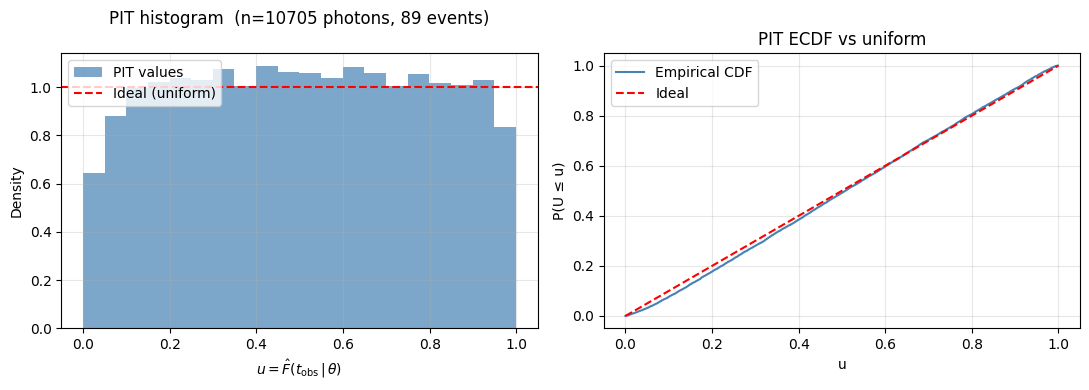

In [18]:


# --- settings ---
N_events    = 300   # (event, detector) pairs to test
n_grid      = 2000   # time-grid resolution per pair for normalization
min_photons = 5     # skip pairs with fewer observed photons
tail_factor = 3.0   # extend grid to t_geom_min + tail_factor*(t_max_obs - t_geom_min)

pit_values = []
n_skipped  = 0

# put network in eval mode so dropout is inactive
if llr_net.mlp_branches is not None:
    for branch in llr_net.mlp_branches:
        branch.eval()
llr_net.final_mlp.eval()

with torch.no_grad():
    for i in range(N_events):
        event = signal_sampler.sample_events(1)[0]

        # find a detector point that sees enough photons
        n_ph = 0
        for _ in range(50):
            point = signal_sampler.sample_detector_points(1)[0]
            patd  = light_yield_surrogate_patd(opt_point=point, event_params=event)
            n_ph  = patd['num_photons']
            if isinstance(n_ph, torch.Tensor):
                n_ph = int(n_ph.item())
            if n_ph >= min_photons:
                break
        if n_ph < min_photons:
            n_skipped += 1
            continue

        obs_times  = patd['hit_times']        # absolute times, (n_ph,)
        t_geom_min = patd['t_geom_min']

        # build a dense absolute-time grid; extend well past the last observed photon
        # (same logspace-in-absolute-time convention as cell above)
        t_start = t_geom_min - 10.0
        t_end   = t_geom_min + tail_factor * (obs_times.max() - t_geom_min) + 100.0
        test_times = torch.logspace(
            torch.log10(t_start).item(),
            torch.log10(t_end).item(),
            steps=n_grid,
        )

        # evaluate network on the grid
        grid_patd = {'hit_times': test_times, 'num_photons': n_grid, 't_geom_min': t_geom_min}
        feats, _  = llr_net.prepare_features_patd(point=point, event_data=event, patd_result=grid_patd)
        raw_lkl   = llr_net.predict_likelihood_ratio(feats)   # (n_grid,)

        # normalise to a proper density via trapz
        norm = torch.trapz(raw_lkl, test_times)
        if not torch.isfinite(norm) or norm <= 0:
            print(f"Skipping event {i+1}/{N_events}: non-finite or non-positive normalization factor ({norm})")
            n_skipped += 1
            continue
        norm_lkl_np = (raw_lkl / norm).cpu().numpy()
        grid_np     = test_times.cpu().numpy()

        # build CDF via cumulative integration, then interpolate at each observed photon time
        cdf = cumulative_trapezoid(norm_lkl_np, grid_np, initial=0.0)
        obs_np   = obs_times.cpu().numpy()
        in_range = (obs_np >= grid_np[0]) & (obs_np <= grid_np[-1])
        if in_range.sum() == 0:
            print(f"Skipping event {i+1}/{N_events}: no observed photons within the grid range")
            n_skipped += 1
            continue
        pit_values.extend(np.interp(obs_np[in_range], grid_np, cdf).tolist())

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{N_events}  |  photons pooled: {len(pit_values)}")

pit_values = np.array(pit_values)
print(f"\nDone: {len(pit_values)} photons from {N_events - n_skipped} events ({n_skipped} skipped)")

# KS test against uniform
ks_stat, ks_pval = stats.kstest(pit_values, 'uniform')
# print(f"KS test: D={ks_stat:.4f},  p={ks_pval:.4f}")

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(pit_values, bins=20, density=True, alpha=0.7, color='steelblue', label='PIT values')
axes[0].axhline(1.0, color='red', linestyle='--', label='Ideal (uniform)')
axes[0].set_xlabel(r'$u = \hat{F}(t_\mathrm{obs}\,|\,\theta)$')
axes[0].set_ylabel('Density')
axes[0].set_title(f'PIT histogram  (n={len(pit_values)} photons, {N_events - n_skipped} events)\n'
                  #f'KS  D={ks_stat:.3f},  p={ks_pval:.3f}'
                  )
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_u = np.sort(pit_values)
ecdf = np.arange(1, len(sorted_u) + 1) / len(sorted_u)
axes[1].plot(sorted_u, ecdf, color='steelblue', label='Empirical CDF')
axes[1].plot([0, 1], [0, 1], 'r--', label='Ideal')
axes[1].set_xlabel('u')
axes[1].set_ylabel('P(U ≤ u)')
axes[1].set_title('PIT ECDF vs uniform')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()